In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, Isomap
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
from sklearn.cluster import KMeans, DBSCAN

# Load Dataset
df = pd.read_csv("C:/Users/DELL/Desktop/archive/Breast_cancer_dataset.csv")
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [8]:
# Encode Diagnosis
le = LabelEncoder()
df["diagnosis"] = le.fit_transform(df["diagnosis"])

In [10]:
# Check dtypes
df.dtypes

id                           int64
diagnosis                    int32
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
concavity_worst     

In [12]:
# Train/Test Split
X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

In [14]:
# fill missing values with the mean
imputer = SimpleImputer(strategy='mean')

# Apply it to the training and test data
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)


C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\impute\_base.py:598: UserWarning: Skipping features without any observed values: ['Unnamed: 32']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\impute\_base.py:598: UserWarning: Skipping features without any observed values: ['Unnamed: 32']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


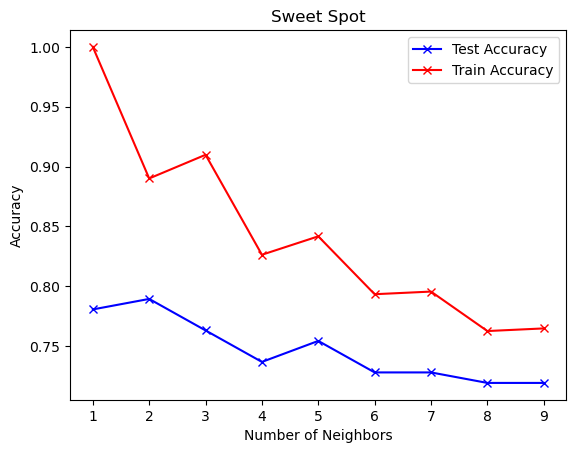

In [16]:
# Lists for k values and accuracy
no_of_neighbors  = []
accuracy = []
train_accuracy = []

# Create and train model
for k in range(1,10):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    # Save accuracy
    no_of_neighbors.append(k)
    accuracy.append(knn.score(X_test, y_test))
    train_accuracy.append(knn.score(X_train, y_train))
    
# Plot accuracy
plt.plot(no_of_neighbors, accuracy, 'bx-', label='Test Accuracy')
plt.plot(no_of_neighbors, train_accuracy, 'rx-', label='Train Accuracy')
plt.xlabel('Number of Neighbors')
plt.ylabel('Accuracy')
plt.title('Sweet Spot')
plt.legend()
plt.show()

In [18]:
knn = KNeighborsClassifier(n_neighbors=4)
knn.fit(X_train, y_train)

# Print the accuracy on the test set
print("KNN Accuracy:", knn.score(X_test, y_test))


KNN Accuracy: 0.7368421052631579


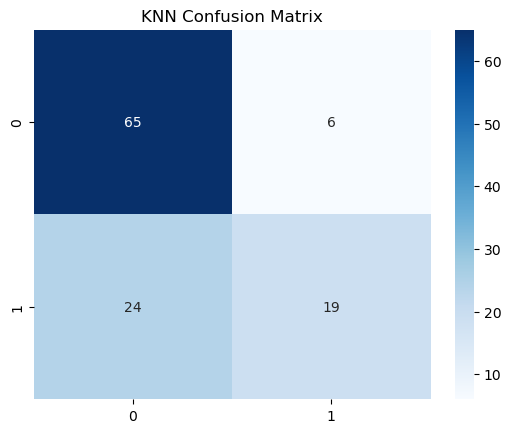

In [20]:
# Confusion Matrix for KNN
y_pred = knn.predict(X_test)
CM = confusion_matrix(y_test, y_pred)

sns.heatmap(CM, annot=True, fmt='d', cmap='Blues')
plt.title("KNN Confusion Matrix")
plt.show()

Target Value Counts:
 diagnosis
0    357
1    212
Name: count, dtype: int64


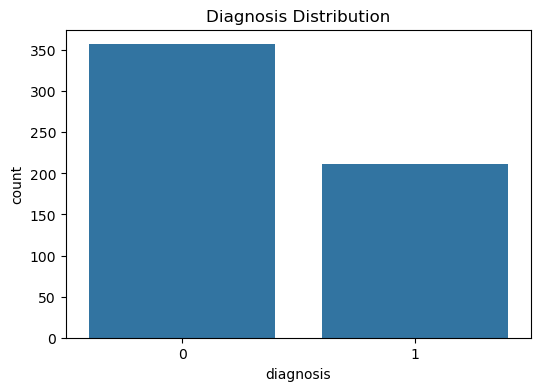

In [22]:
# Diagnosis Count Plot
print("Target Value Counts:\n", df["diagnosis"].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x="diagnosis", data=df)
plt.title("Diagnosis Distribution")
plt.show()


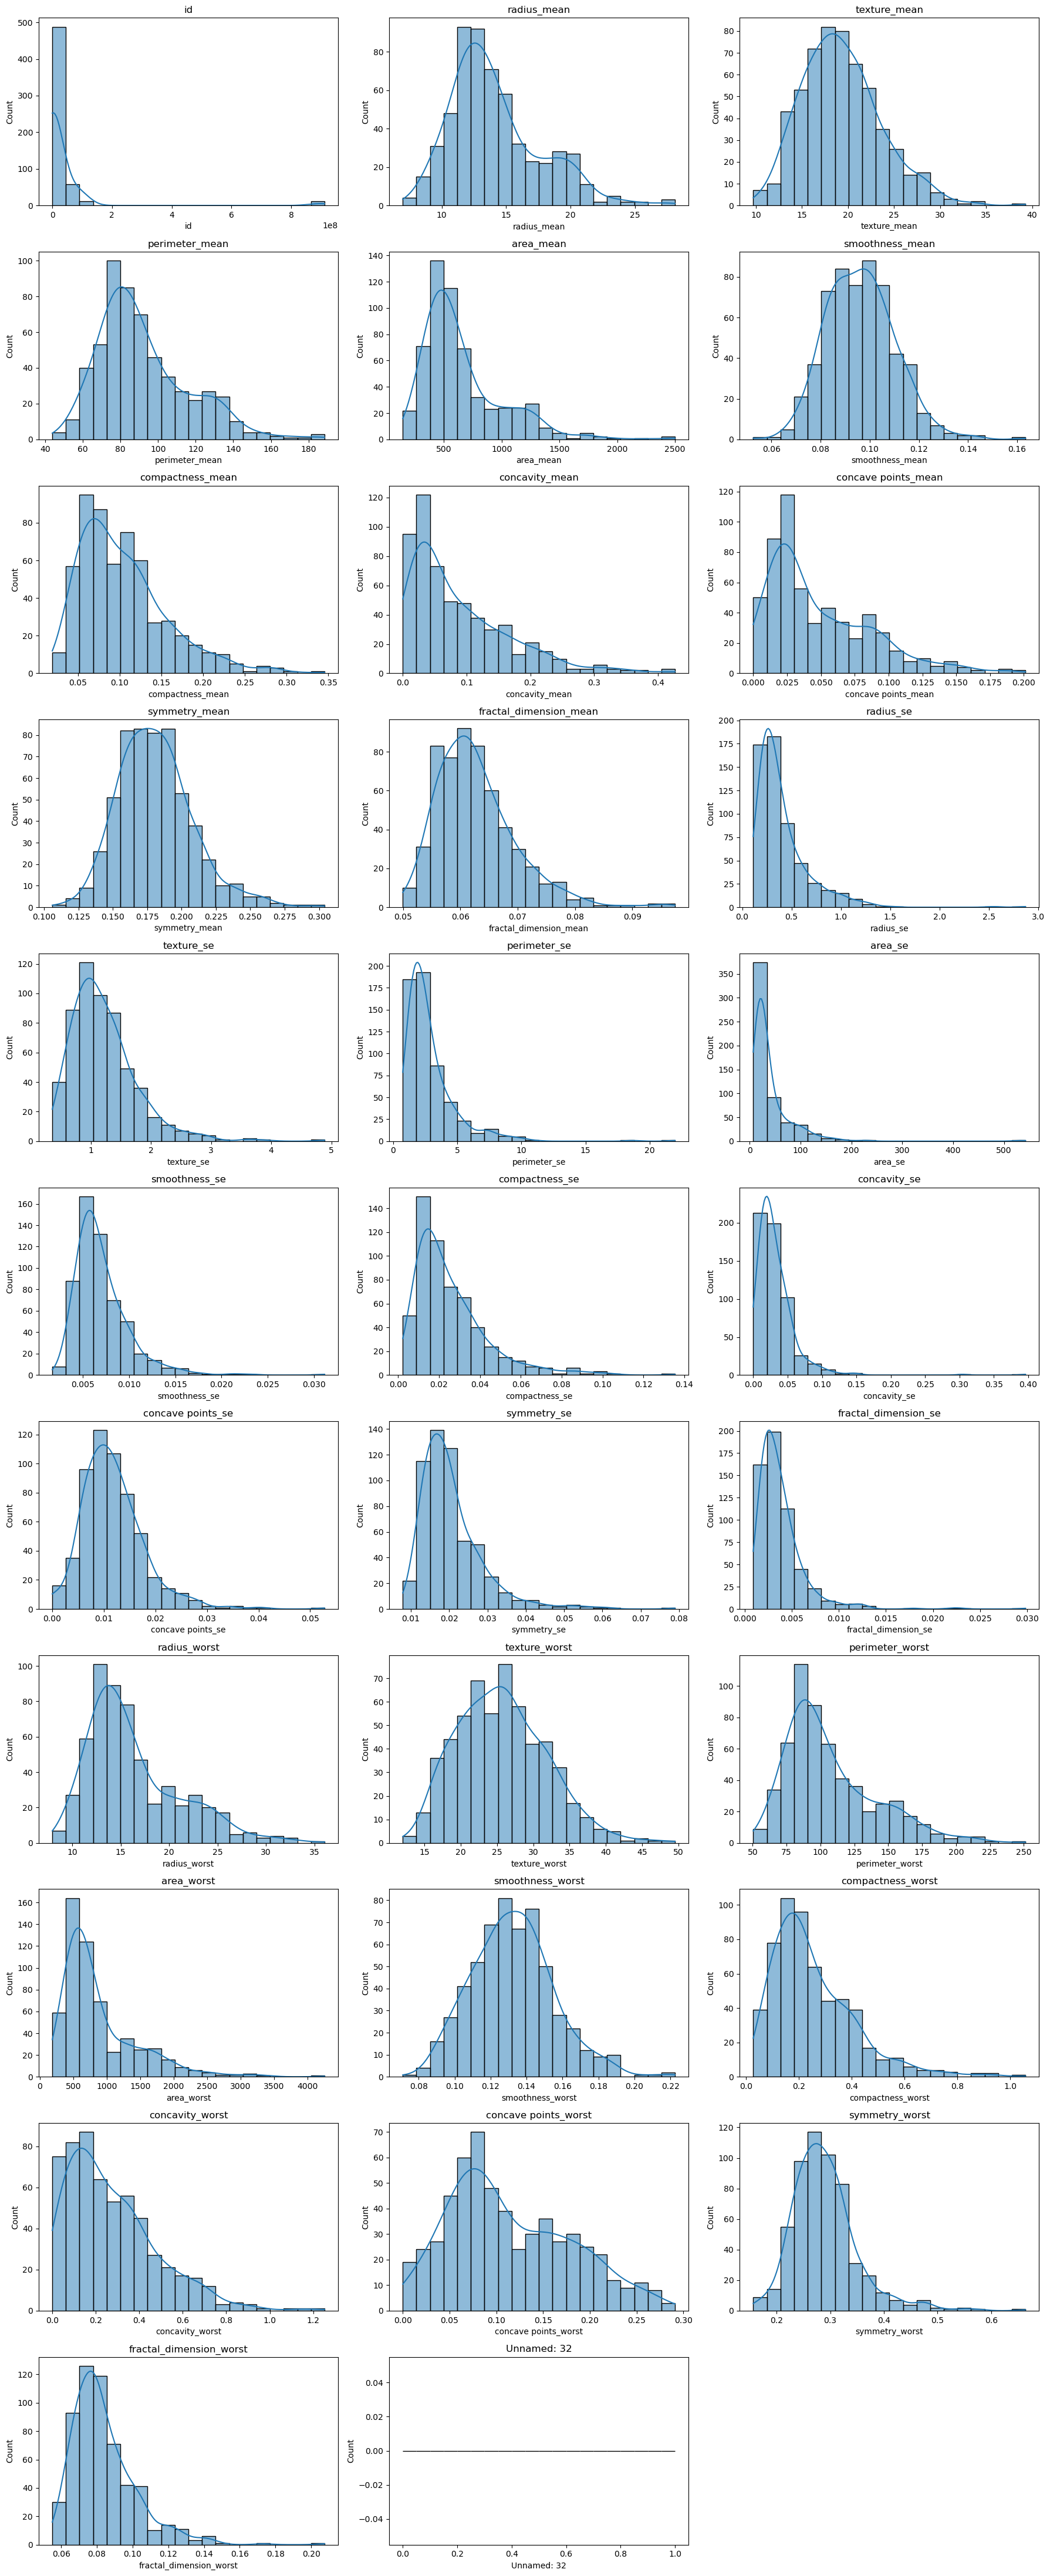

In [24]:
numerical_features = df.select_dtypes(include=['int64','float64']).columns.tolist()
numerical_features.remove('diagnosis') if 'diagnosis' in numerical_features else None

n_cols = 3
n_rows = (len(numerical_features) + n_cols - 1) // n_cols

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows*4))
axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    sns.histplot(df[feature], bins=20, kde=True, ax=axes[i])
    axes[i].set_title(feature)
    
# Remove any empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
    
# display the plots
plt.tight_layout()
plt.show()

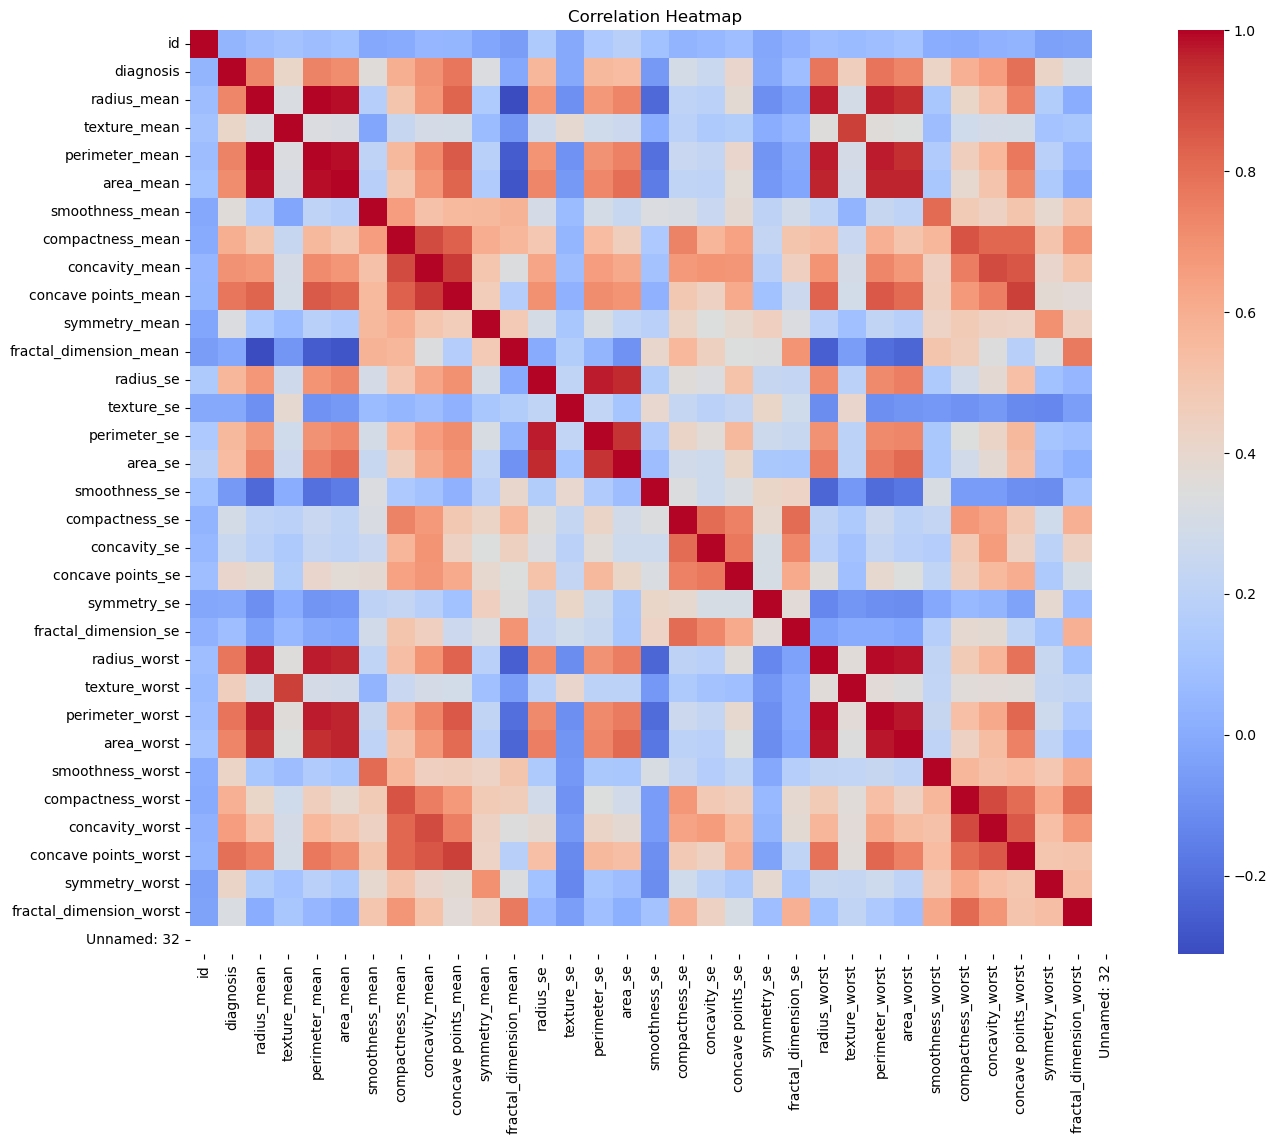

In [26]:
# Correlation Heatmap
plt.figure(figsize=(15, 12))
corr = df.corr()
sns.heatmap(corr, annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

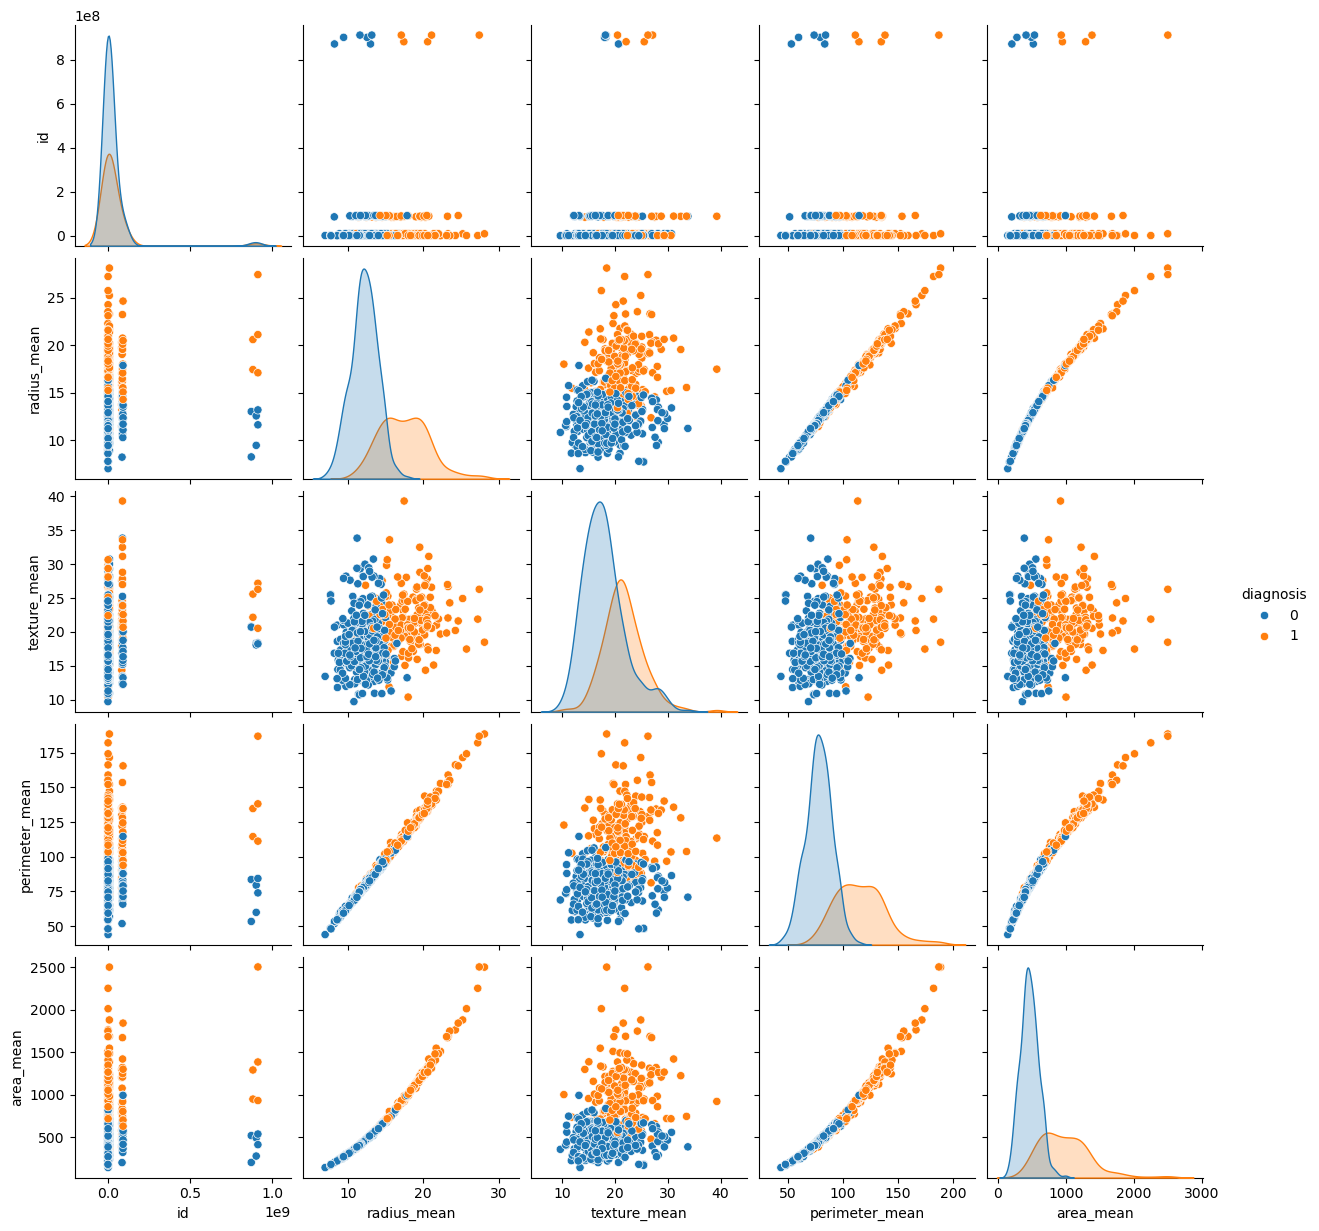

In [28]:
# Pairplot for Selected Features
numerical_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
selected_features = numerical_features[:5] + ["diagnosis"]

sns.pairplot(df[selected_features], hue="diagnosis")
plt.show()

In [30]:
# Define a dictionary of models to train
models = {
    "RandomForest": RandomForestClassifier(random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "MLP": MLPClassifier(random_state=42, activation="relu", hidden_layer_sizes=(100,), max_iter=500)
}

# Train each model and print training and test scores
for name, model in models.items():
    model.fit(X_train, y_train)
    print(name)
    print("Train Score:", model.score(X_train, y_train))
    print("Test Score:", model.score(X_test, y_test))
    print("------------")


RandomForest
Train Score: 1.0
Test Score: 0.9649122807017544
------------
GradientBoosting
Train Score: 1.0
Test Score: 0.9473684210526315
------------
MLP
Train Score: 0.6351648351648351
Test Score: 0.631578947368421
------------


In [32]:
# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Quick check
print("X_scaled shape:", X_scaled.shape)
print("y shape:", y.shape)

X_scaled shape: (569, 32)
y shape: (569,)


C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1137: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1142: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1162: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


In [34]:
#fill missing values with the mean
imputer = SimpleImputer(strategy='mean')
X_scaled = imputer.fit_transform(X_scaled)

C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\impute\_base.py:598: UserWarning: Skipping features without any observed values: [31]. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


Explained variance ratio: [0.42864701 0.18376792]


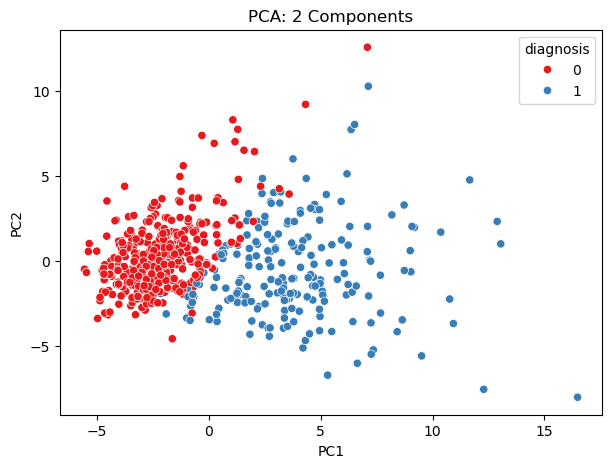

In [36]:
# PCA (Principal Component Analysis) 
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print("Explained variance ratio:", pca.explained_variance_ratio_)

plt.figure(figsize=(7,5))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y, palette='Set1')
plt.title("PCA: 2 Components")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


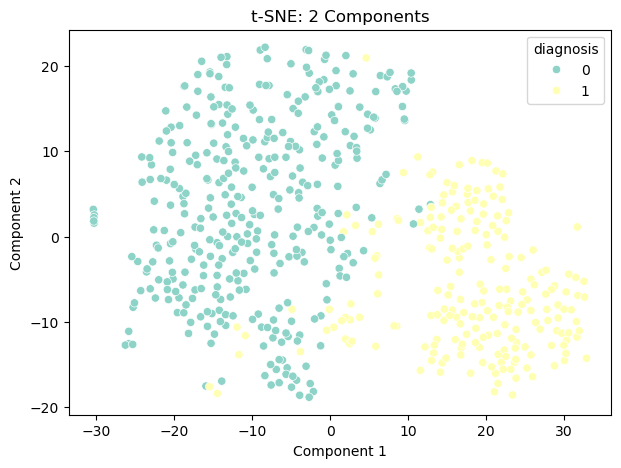

In [38]:
# Apply t-SNE with 2 components and fit the scaled data
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

# Create a scatter plot of t-SNE result
plt.figure(figsize=(7,5))
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=y, palette='Set3')
plt.title("t-SNE: 2 Components")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

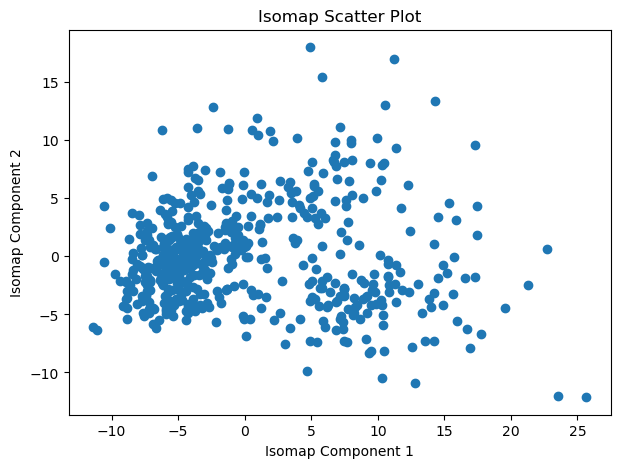

In [39]:
# Apply Isomap with 2 components and fit the scaled data
isomap = Isomap(n_components=2)
X_isomap = isomap.fit_transform(X_scaled)

# Create a scatter plot of the Isomap result
plt.figure(figsize=(7,5))
plt.scatter(X_isomap[:,0], X_isomap[:,1])
plt.xlabel("Isomap Component 1")
plt.ylabel("Isomap Component 2")
plt.title("Isomap Scatter Plot")
plt.show()

In [42]:
#Decision Tree Model
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [44]:
# Evaluation
y_pred = model.predict(X_test)
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.9385964912280702

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95        71
           1       0.91      0.93      0.92        43

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114



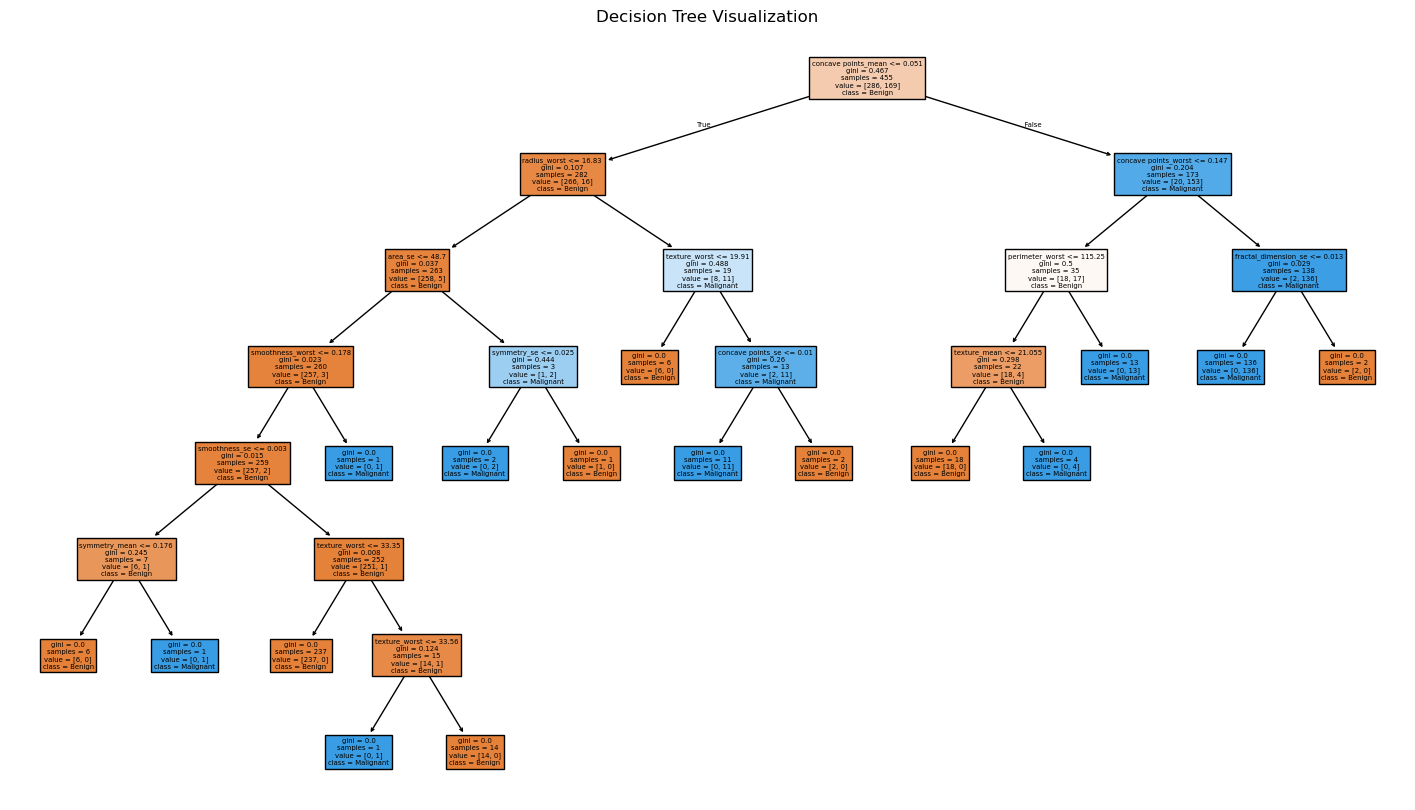

In [46]:
# Plot Decision Tree
plt.figure(figsize=(18, 10))
plot_tree(model, feature_names=X.columns, class_names=['Benign', 'Malignant'], filled=True)
plt.title("Decision Tree Visualization")
plt.show()

In [139]:
# K-Means Clustering
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

print("\nK-Means Labels:")
print(kmeans_labels[:20])


K-Means Labels:
[0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 1 0 0 1]


C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


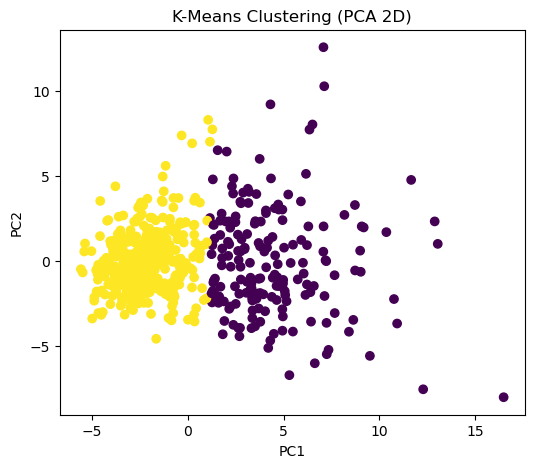

In [141]:
# Visualize K-Means using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels)
plt.title("K-Means Clustering (PCA 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()